In [ ]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.visualizacao import aplicar_estilo_dark, estilizar_grafico, adicionar_valores_barras, COR_VERMELHO, COR_AZUL, COR_AMARELO

aplicar_estilo_dark()

In [2]:
df = pd.read_csv("../data/processed/dataset_final_resumo_limpo.csv")

top_kd = df.groupby("Fighter")["KD"].sum().sort_values(ascending=False).head(10)

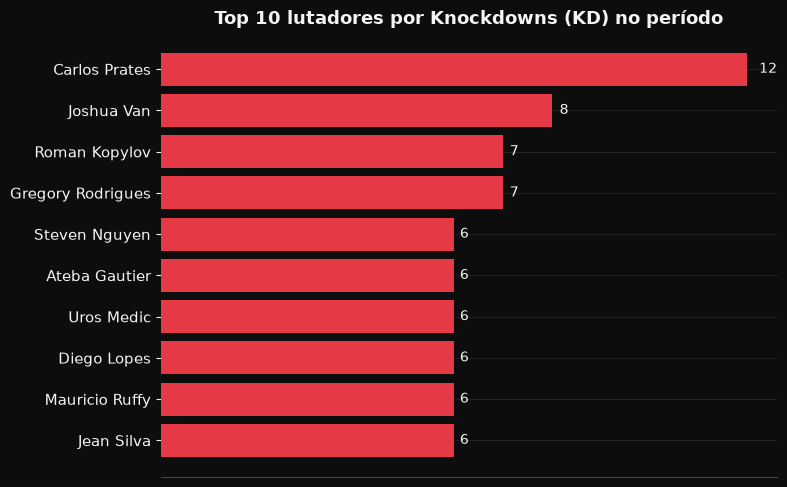

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_kd.index[::-1], top_kd.values[::-1], color=COR_VERMELHO)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por Knockdowns (KD) no período")

plt.tight_layout()
plt.savefig("../figures/top10_kd.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

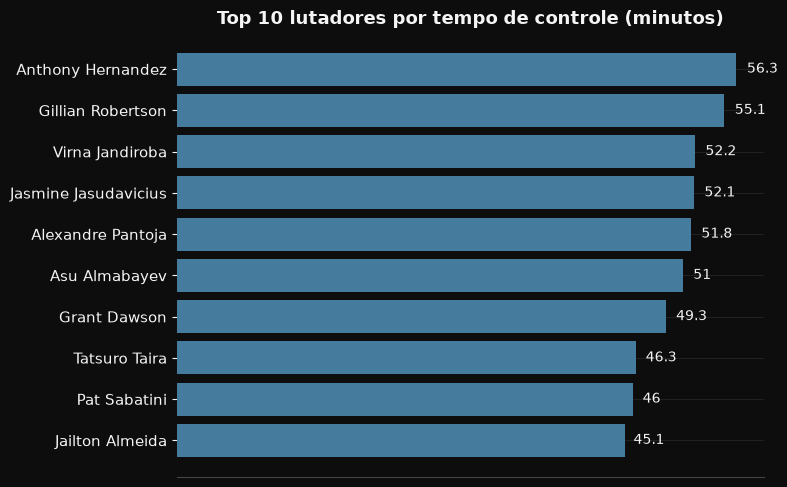

In [4]:
df_proc = pd.read_csv("../data/processed/dataset_24eventos_resumo_limpo.csv") if False else pd.read_csv("../data/processed/dataset_final_resumo_limpo.csv")

top_ctrl = df_proc.groupby("Fighter")["Ctrl_seconds"].sum().sort_values(ascending=False).head(10)
top_ctrl_min = (top_ctrl / 60).round(1)  # converter para minutos, mais legível

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_ctrl_min.index[::-1], top_ctrl_min.values[::-1], color=COR_AZUL)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por tempo de controle (minutos)")

plt.tight_layout()
plt.savefig("../figures/top10_ctrl.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

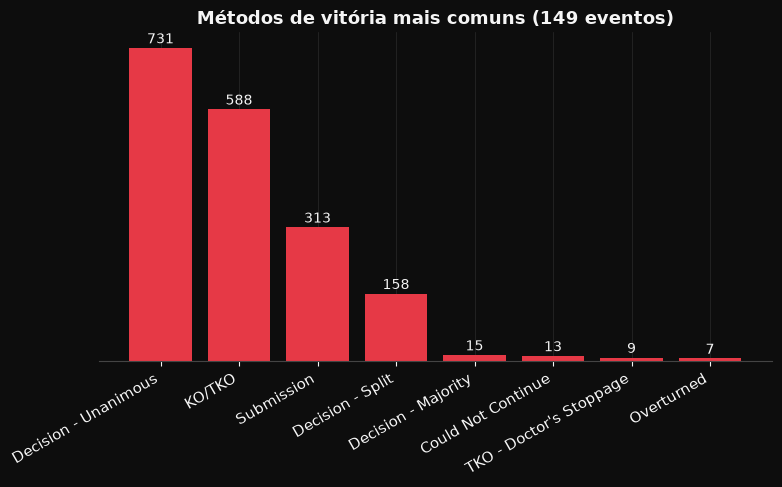

In [3]:
# Uma linha por luta: o dataset tem uma por lutador, o que contaria cada luta duas vezes
metodos = df.drop_duplicates("Fight_URL")["Method"].value_counts().head(8)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(metodos.index, metodos.values, color=COR_VERMELHO)

for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + metodos.max() * 0.015,
            f"{int(altura)}", ha="center", fontsize=10, color="#f5f5f5")

ax.set_title("Métodos de vitória mais comuns (149 eventos)", fontsize=13, fontweight="bold")
ax.set_yticks([])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/metodos_vitoria.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

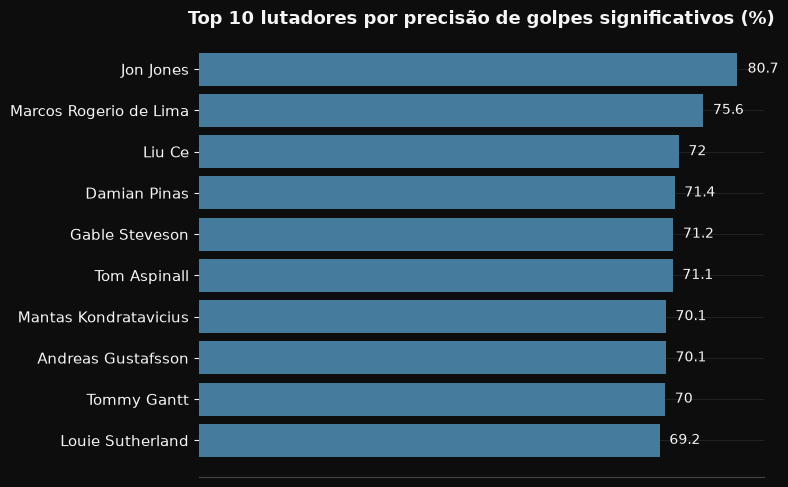

In [6]:
precisao = df.groupby("Fighter").agg(
    total_landed=("Sig_str_landed", "sum"),
    total_attempted=("Sig_str_attempted", "sum")
)
precisao = precisao[precisao["total_attempted"] >= 50]  # filtro: pelo menos 50 tentativas no período
precisao["precisao_pct"] = (precisao["total_landed"] / precisao["total_attempted"] * 100).round(1)

top_precisao = precisao.sort_values("precisao_pct", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_precisao.index[::-1], top_precisao["precisao_pct"].values[::-1], color=COR_AZUL)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por precisão de golpes significativos (%)")

plt.tight_layout()
plt.savefig("../figures/top10_precisao.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

In [9]:
def comparar_lutadores(nome1, nome2, df):
    metricas = ["Sig_str_landed", "Total_str_landed", "Td_landed", "Sub. att", "KD"]
    labels = ["Golpes Sig. (méd/luta)", "Golpes Totais (méd/luta)", "Quedas (méd/luta)", "Finaliz. Tent. (méd/luta)", "Knockdowns (méd/luta)"]

    df1 = df[df["Fighter"] == nome1]
    df2 = df[df["Fighter"] == nome2]

    n_lutas1 = len(df1)
    n_lutas2 = len(df2)

    dados1 = df1[metricas].mean().round(1)
    dados2 = df2[metricas].mean().round(1)

    y_pos = range(len(metricas))
    escala_max = max(dados1.max(), dados2.max())

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(y_pos, -dados1.values, color=COR_AZUL, label=f"{nome1} ({n_lutas1} lutas)")
    ax.barh(y_pos, dados2.values, color=COR_VERMELHO, label=f"{nome2} ({n_lutas2} lutas)")

    for i, v in enumerate(dados1.values):
        ax.text(-v - (escala_max * 0.03), i, f"{v}", va="center", ha="right", fontsize=10, color="#f5f5f5")
    for i, v in enumerate(dados2.values):
        ax.text(v + (escala_max * 0.03), i, f"{v}", va="center", ha="left", fontsize=10, color="#f5f5f5")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xticks([])
    ax.set_title(f"{nome1}  vs  {nome2}  —  médias por luta", fontsize=14, fontweight="bold")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, labelcolor="#f5f5f5")

    plt.tight_layout()
    nome_arquivo = f"../figures/comparacao_{nome1.replace(' ', '_')}_vs_{nome2.replace(' ', '_')}.png"
    plt.savefig(nome_arquivo, dpi=150, facecolor=fig.get_facecolor())
    plt.show()

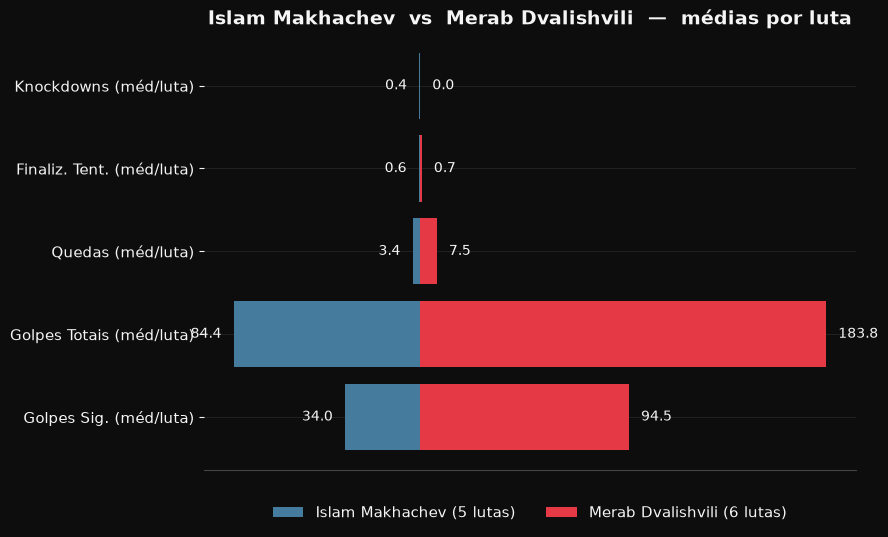

In [12]:
comparar_lutadores("Islam Makhachev", "Merab Dvalishvili", df)

In [13]:
df_round = pd.read_csv("../data/processed/dataset_final_round_limpo.csv")

media_por_round = df_round.groupby("Round")["Sig_str_landed"].mean().round(1)
print(media_por_round)

Round
1    16.2
2    18.9
3    19.7
4    19.6
5    20.5
Name: Sig_str_landed, dtype: float64


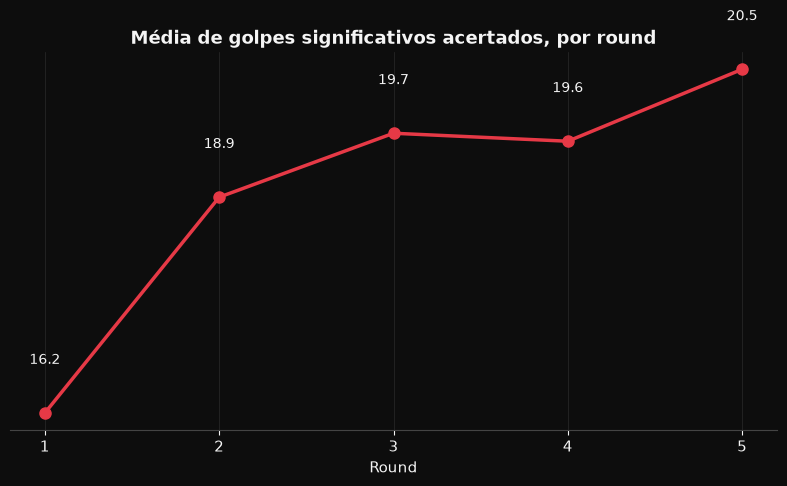

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(media_por_round.index, media_por_round.values, color=COR_VERMELHO,
        marker="o", markersize=8, linewidth=2.5)

for x, y in zip(media_por_round.index, media_por_round.values):
    ax.text(x, y + (media_por_round.max() * 0.03), f"{y}",
            ha="center", fontsize=10, color="#f5f5f5")

ax.set_title("Média de golpes significativos acertados, por round", fontsize=13, fontweight="bold")
ax.set_xlabel("Round")
ax.set_xticks(media_por_round.index)
ax.set_yticks([])
plt.tight_layout()
plt.savefig("../figures/evolucao_golpes_por_round.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

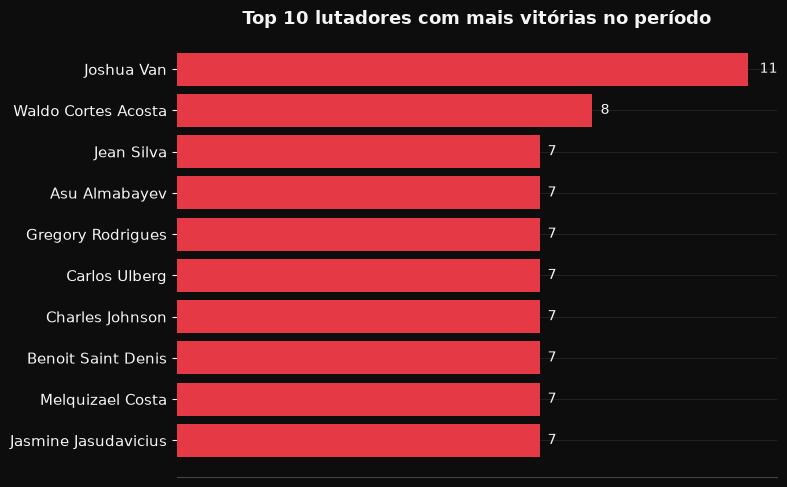

In [15]:
vitorias = df[df["Resultado"] == "W"].groupby("Fighter").size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(vitorias.index[::-1], vitorias.values[::-1], color=COR_VERMELHO)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores com mais vitórias no período")

plt.tight_layout()
plt.savefig("../figures/top10_vitorias.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

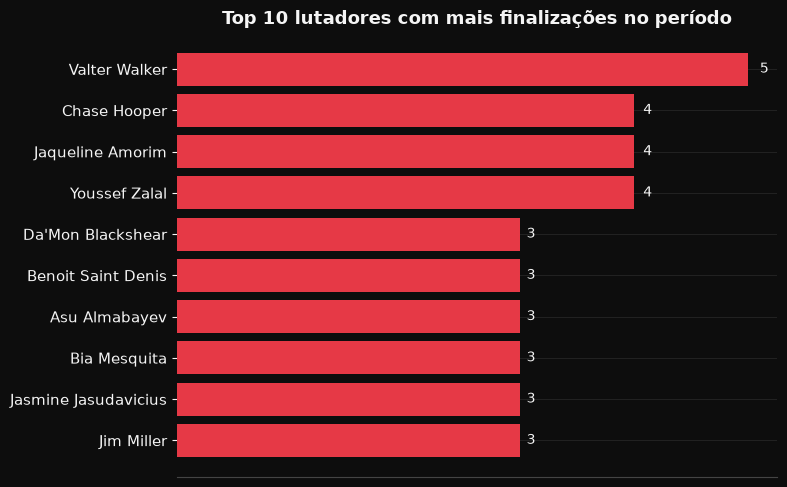

In [3]:
finalizacoes = df[
    (df["Resultado"] == "W") & (df["Method"].str.contains("Submission", na=False))
].groupby("Fighter").size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(finalizacoes.index[::-1], finalizacoes.values[::-1], color=COR_VERMELHO)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores com mais finalizações no período")

plt.tight_layout()
plt.savefig("../figures/top10_finalizacoes.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

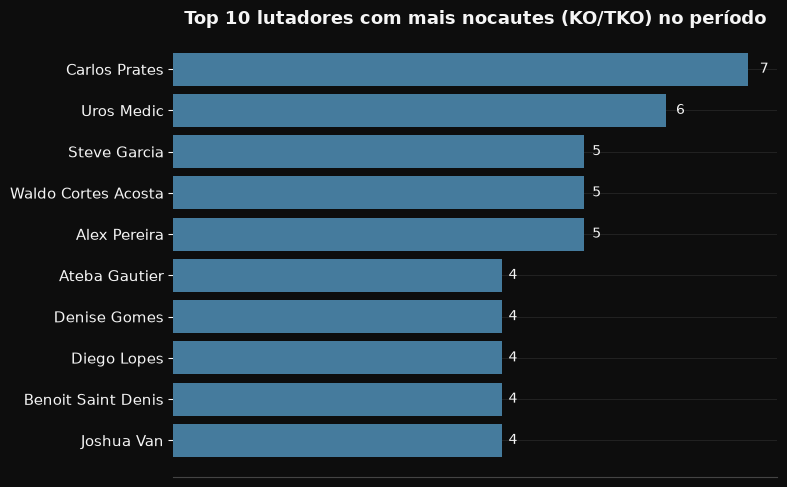

In [18]:
nocautes = df[
    (df["Resultado"] == "W") & (df["Method"].str.contains("KO/TKO", na=False))
].groupby("Fighter").size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(nocautes.index[::-1], nocautes.values[::-1], color=COR_AZUL)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores com mais nocautes (KO/TKO) no período")

plt.tight_layout()
plt.savefig("../figures/top10_nocautes.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

           Sig_str_landed  Td_landed  Ctrl_minutos  Sub. att    KD
Resultado                                                         
L                   35.42       0.67          1.32      0.15  0.05
W                   51.99       1.41          2.82      0.40  0.40


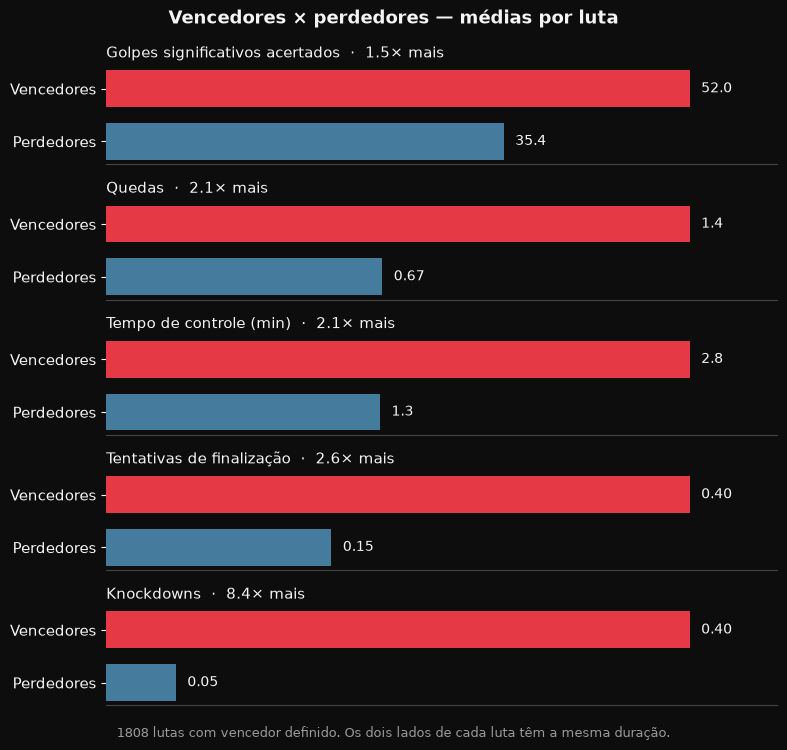

In [3]:
# Vencedores x perdedores: médias por luta, só lutas com resultado (sem empate/NC).
# Cada métrica tem escala própria, então um painel por métrica em vez de um eixo único.
metricas_wl = {
    "Golpes significativos acertados": "Sig_str_landed",
    "Quedas": "Td_landed",
    "Tempo de controle (min)": "Ctrl_minutos",
    "Tentativas de finalização": "Sub. att",
    "Knockdowns": "KD",
}

df_wl = df[df["Resultado"].isin(["W", "L"])].copy()
df_wl["Ctrl_minutos"] = df_wl["Ctrl_seconds"] / 60
medias_wl = df_wl.groupby("Resultado")[list(metricas_wl.values())].mean()
print(medias_wl.round(2))

fig, axes = plt.subplots(len(metricas_wl), 1, figsize=(8, 7.5))

for ax, (rotulo, coluna) in zip(axes, metricas_wl.items()):
    v, p = medias_wl.loc["W", coluna], medias_wl.loc["L", coluna]
    barras = ax.barh(["Perdedores", "Vencedores"], [p, v], color=[COR_AZUL, COR_VERMELHO], height=0.7)

    for barra in barras:
        valor = barra.get_width()
        ax.text(valor + v * 0.02, barra.get_y() + barra.get_height() / 2,
                f"{valor:.1f}" if valor >= 1 else f"{valor:.2f}",
                va="center", fontsize=10, color="#f5f5f5")

    ax.set_title(f"{rotulo}  ·  {v / p:.1f}× mais", fontsize=11, loc="left", color="#f5f5f5")
    ax.set_xlim(0, v * 1.15)
    ax.set_xticks([])
    ax.grid(False)

fig.suptitle("Vencedores × perdedores — médias por luta", fontsize=13, fontweight="bold")
fig.text(0.5, 0.01, f"{len(df_wl) // 2} lutas com vencedor definido. Os dois lados de cada luta têm a mesma duração.",
         ha="center", fontsize=9, color="#9a9a9a")

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig("../figures/vencedores_vs_perdedores.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

487 lutadores | medianas: 8.2 golpes/min, 48.0%


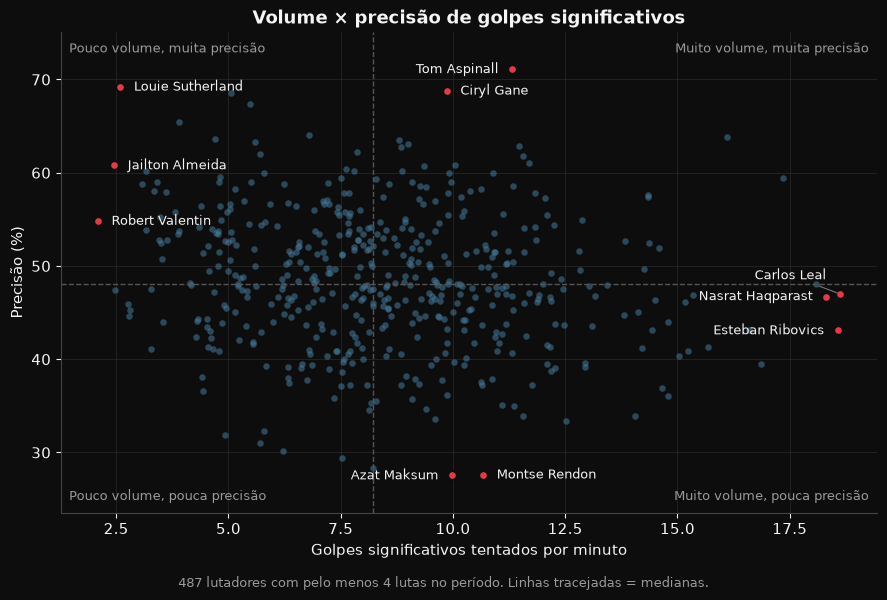

In [3]:
# Volume x precisão: volume em golpes significativos TENTADOS por minuto de luta
# (por luta puniria quem finaliza cedo), precisão = acertados / tentados no período.
from src.limpeza import tempo_para_segundos

MIN_LUTAS = 4

df_vp = tempo_para_segundos(df.copy(), "Time")
df_vp["Duracao_seg"] = (df_vp["Final_Round"] - 1) * 300 + df_vp["Time_seconds"]

vp = df_vp.groupby("Fighter").agg(
    lutas=("Fight_URL", "nunique"),
    landed=("Sig_str_landed", "sum"),
    attempted=("Sig_str_attempted", "sum"),
    duracao=("Duracao_seg", "sum"),
)
vp = vp[vp["lutas"] >= MIN_LUTAS]
vp["volume_min"] = vp["attempted"] / (vp["duracao"] / 60)
vp["precisao_pct"] = vp["landed"] / vp["attempted"] * 100

med_vol, med_prec = vp["volume_min"].median(), vp["precisao_pct"].median()
print(f"{len(vp)} lutadores | medianas: {med_vol:.1f} golpes/min, {med_prec:.1f}%")

# Destaques: extremos de cada eixo
destaques = pd.concat([
    vp.nlargest(3, "volume_min"), vp.nsmallest(2, "volume_min"),
    vp.nlargest(3, "precisao_pct"), vp.nsmallest(2, "precisao_pct"),
])
destaques = destaques[~destaques.index.duplicated()]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(vp["volume_min"], vp["precisao_pct"], s=22, color=COR_AZUL, alpha=0.55, linewidths=0)
ax.scatter(destaques["volume_min"], destaques["precisao_pct"], s=40, color=COR_VERMELHO,
           edgecolors="#0d0d0d", linewidths=1.5, zorder=3)

ax.axvline(med_vol, color="#555555", linestyle="--", linewidth=1)
ax.axhline(med_prec, color="#555555", linestyle="--", linewidth=1)
ax.set_ylim(vp["precisao_pct"].min() - 4, vp["precisao_pct"].max() + 4)

# Rótulos: à esquerda se o ponto está na borda direita ou se outro destaque está logo à direita;
# no mesmo lado, empurra para cima quem ficaria colado em outro rótulo
limite_direita = vp["volume_min"].quantile(0.8)
ja_colocados = []  # (x, y do texto, lado)
for nome, linha in destaques.sort_values("precisao_pct").iterrows():
    x, y = linha["volume_min"], linha["precisao_pct"]
    vizinho_a_direita = ((destaques["volume_min"] - x).between(0.01, 3.5)
                         & ((destaques["precisao_pct"] - y).abs() < 1.5)).any()
    a_esquerda = x > limite_direita or vizinho_a_direita

    y_texto = y
    while any(lado == a_esquerda and abs(x - px) < 3 and abs(y_texto - py) < 2 for px, py, lado in ja_colocados):
        y_texto += 2
    ja_colocados.append((x, y_texto, a_esquerda))

    ax.annotate(nome, (x, y), xytext=(x + (-0.3 if a_esquerda else 0.3), y_texto),
                ha="right" if a_esquerda else "left", va="center", fontsize=9, color="#f5f5f5",
                arrowprops=dict(arrowstyle="-", color="#777777", linewidth=0.8) if y_texto != y else None)

# Rótulos dos quadrantes, nos cantos
cor_quadrante = "#9a9a9a"
ax.text(0.99, 0.98, "Muito volume, muita precisão", transform=ax.transAxes, ha="right", va="top", fontsize=9, color=cor_quadrante)
ax.text(0.01, 0.98, "Pouco volume, muita precisão", transform=ax.transAxes, ha="left", va="top", fontsize=9, color=cor_quadrante)
ax.text(0.99, 0.02, "Muito volume, pouca precisão", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color=cor_quadrante)
ax.text(0.01, 0.02, "Pouco volume, pouca precisão", transform=ax.transAxes, ha="left", va="bottom", fontsize=9, color=cor_quadrante)

ax.set_title("Volume × precisão de golpes significativos", fontsize=13, fontweight="bold")
ax.set_xlabel("Golpes significativos tentados por minuto")
ax.set_ylabel("Precisão (%)")
ax.spines["left"].set_visible(True)
fig.text(0.5, 0.01, f"{len(vp)} lutadores com pelo menos {MIN_LUTAS} lutas no período. Linhas tracejadas = medianas.",
         ha="center", fontsize=9, color="#9a9a9a")

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig("../figures/volume_vs_precisao.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

231 lutadores com pelo menos 6 lutas
Resultado          W  L  D  lutas    taxa_pct
Fighter                                      
Carlos Ulberg      7  0  0      7  100.000000
Ailin Perez        6  0  0      6  100.000000
Farid Basharat     6  0  0      6  100.000000
Natalia Silva      6  0  0      6  100.000000
Navajo Stirling    6  0  0      6  100.000000
Quillan Salkilld   6  0  0      6  100.000000
Joshua Van        11  1  0     12   91.666667
Asu Almabayev      7  1  0      8   87.500000
Carlos Prates      7  1  0      8   87.500000
Denise Gomes       7  1  0      8   87.500000


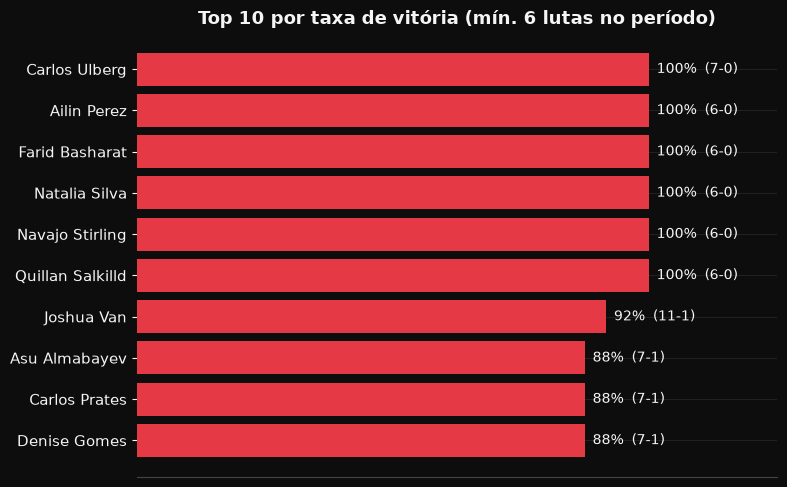

In [3]:
# Taxa de vitória: corrige o viés do top 10 por vitórias (que favorece quem lutou mais).
# Denominador = vitórias + derrotas + empates (NC fica de fora). Com menos de 6 lutas
# o top 10 vira só invictos de 100%; empate na taxa é desempatado pelo nº de vitórias.
MIN_LUTAS_TAXA = 6

cartel = pd.crosstab(df["Fighter"], df["Resultado"]).reindex(columns=["W", "L", "D"], fill_value=0)
cartel["lutas"] = cartel[["W", "L", "D"]].sum(axis=1)
cartel = cartel[cartel["lutas"] >= MIN_LUTAS_TAXA]
cartel["taxa_pct"] = cartel["W"] / cartel["lutas"] * 100

top_taxa = cartel.sort_values(["taxa_pct", "W"], ascending=False).head(10)
print(f"{len(cartel)} lutadores com pelo menos {MIN_LUTAS_TAXA} lutas")
print(top_taxa)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_taxa.index[::-1], top_taxa["taxa_pct"].values[::-1], color=COR_VERMELHO)

# Valor na ponta com o cartel (V-D, e -E se houver empate), para mostrar o tamanho da amostra
for barra, (_, linha) in zip(barras, top_taxa[::-1].iterrows()):
    v, d, e = int(linha["W"]), int(linha["L"]), int(linha["D"])
    cartel_txt = f"{v}-{d}" + (f"-{e}" if e else "")
    ax.text(barra.get_width() + 1.5, barra.get_y() + barra.get_height() / 2,
            f"{linha['taxa_pct']:.0f}%  ({cartel_txt})", va="center", fontsize=10, color="#f5f5f5")

estilizar_grafico(ax, f"Top 10 por taxa de vitória (mín. {MIN_LUTAS_TAXA} lutas no período)")
ax.set_xlim(0, 125)

plt.tight_layout()
plt.savefig("../figures/top10_taxa_vitoria.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

Metodo       Finalização (submission)  Nocaute (KO/TKO)
Round_grupo                                            
1º                                144               320
2º                                109               176
3º                                 56                90
4º ou 5º                            4                11
Metodo       Finalização (submission)  Nocaute (KO/TKO)
Round_grupo                                            
1º                               46.0              53.6
2º                               34.8              29.5
3º                               17.9              15.1
4º ou 5º                          1.3               1.8


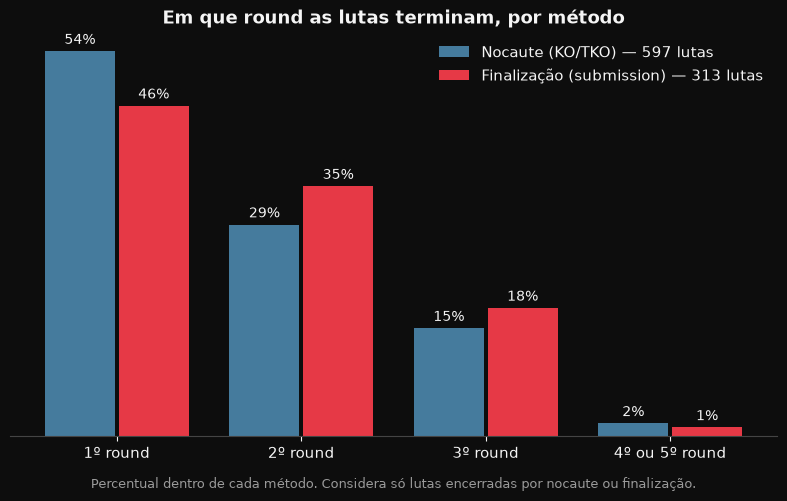

In [3]:
# Em que round as lutas terminam, por método. Uma linha por luta (o dataset tem uma por lutador).
# "TKO - Doctor's Stoppage" conta como nocaute. Rounds 4 e 5 só existem em lutas de 5 rounds
# e somam poucos casos, então viram uma categoria só. Percentual dentro de cada método,
# porque há quase o dobro de nocautes que de finalizações.
import numpy as np

lutas_unicas = df.drop_duplicates("Fight_URL")
metodo_final = np.select(
    [lutas_unicas["Method"].str.contains("KO/TKO|TKO - Doctor", na=False),
     lutas_unicas["Method"].str.contains("Submission", na=False)],
    ["Nocaute (KO/TKO)", "Finalização (submission)"], default=None,
)
finais = lutas_unicas.assign(Metodo=metodo_final).dropna(subset=["Metodo"])
finais["Round_grupo"] = finais["Final_Round"].map({1: "1º", 2: "2º", 3: "3º", 4: "4º ou 5º", 5: "4º ou 5º"})

contagem = pd.crosstab(finais["Round_grupo"], finais["Metodo"]).reindex(["1º", "2º", "3º", "4º ou 5º"])
pct = contagem / contagem.sum() * 100
print(contagem)
print(pct.round(1))

metodos_cores = {"Nocaute (KO/TKO)": COR_AZUL, "Finalização (submission)": COR_VERMELHO}
x = np.arange(len(pct))
largura = 0.38

fig, ax = plt.subplots(figsize=(8, 5))
for i, (metodo, cor) in enumerate(metodos_cores.items()):
    deslocamento = (i - 0.5) * (largura + 0.02)
    barras = ax.bar(x + deslocamento, pct[metodo], width=largura, color=cor,
                    label=f"{metodo} — {contagem[metodo].sum()} lutas")
    for barra in barras:
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 1,
                f"{barra.get_height():.0f}%", ha="center", fontsize=10, color="#f5f5f5")

ax.set_xticks(x)
ax.set_xticklabels([f"{r} round" for r in pct.index])
ax.set_yticks([])
ax.grid(False)
ax.set_title("Em que round as lutas terminam, por método", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", frameon=False, labelcolor="#f5f5f5")
fig.text(0.5, 0.01, "Percentual dentro de cada método. Considera só lutas encerradas por nocaute ou finalização.",
         ha="center", fontsize=9, color="#9a9a9a")

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig("../figures/round_final_por_metodo.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

426 lutadores com pelo menos 150 golpes acertados
                    Head_landed  Body_landed  Leg_landed
Todos os lutadores         62.6         21.1        16.3
Jacob Malkoun              94.0          6.0         0.0
Ty Miller                  91.7          7.8         0.5
Josh Hokit                 90.0          8.4         1.6
Rafael Fiziev              36.8         46.4        16.7
Michael Johnson            39.7         44.7        15.5
Michel Pereira             45.0         42.7        12.3
Chris Gutierrez            34.9          7.3        57.8
Johnny Walker              36.7          9.7        53.6
Armen Petrosyan            35.7         14.9        49.3


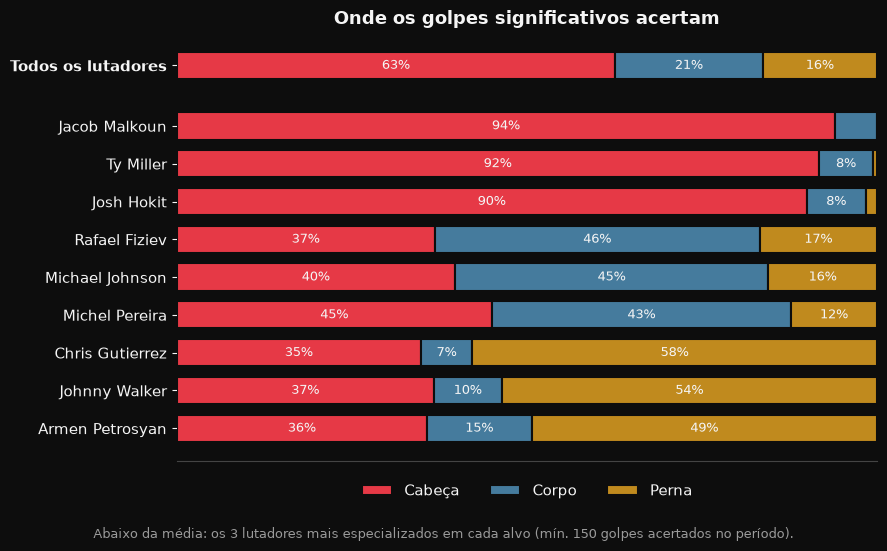

In [3]:
# Onde os golpes significativos acertam: cabeça, corpo e perna, em % do total acertado.
# Primeira barra = todos os lutadores; depois os 3 mais especializados em cada alvo
# (mínimo de 150 golpes acertados no período, para o percentual não vir de poucos golpes).
import numpy as np

MIN_GOLPES_ALVO = 150
alvos = {"Cabeça": ("Head_landed", COR_VERMELHO), "Corpo": ("Body_landed", COR_AZUL), "Perna": ("Leg_landed", COR_AMARELO)}
colunas_alvo = [col for col, _ in alvos.values()]

por_lutador = df.groupby("Fighter")[colunas_alvo].sum()
por_lutador = por_lutador[por_lutador.sum(axis=1) >= MIN_GOLPES_ALVO]
pct_lutador = por_lutador.div(por_lutador.sum(axis=1), axis=0) * 100

total_geral = df[colunas_alvo].sum()
linha_geral = (total_geral / total_geral.sum() * 100).to_frame("Todos os lutadores").T

especialistas = pd.concat([pct_lutador.nlargest(3, col) for col in colunas_alvo])
tabela = pd.concat([linha_geral, especialistas])
print(f"{len(por_lutador)} lutadores com pelo menos {MIN_GOLPES_ALVO} golpes acertados")
print(tabela.round(1))

fig, ax = plt.subplots(figsize=(9, 5.5))
posicoes = list(range(len(tabela)))[::-1]
posicoes = [p if i == 0 else p - 0.6 for i, p in enumerate(posicoes)]  # espaço entre a média e os especialistas

esquerda = np.zeros(len(tabela))
for rotulo, (coluna, cor) in alvos.items():
    valores = tabela[coluna].values
    ax.barh(posicoes, valores, left=esquerda, color=cor, height=0.72, label=rotulo,
            edgecolor="#0d0d0d", linewidth=1.5)
    for y, x0, v in zip(posicoes, esquerda, valores):
        if v >= 7:  # segmento pequeno demais não comporta o texto
            ax.text(x0 + v / 2, y, f"{v:.0f}%", ha="center", va="center", fontsize=9.5, color="#f5f5f5")
    esquerda += valores

ax.set_yticks(posicoes)
ax.set_yticklabels(tabela.index)
ax.get_yticklabels()[0].set_fontweight("bold")
ax.set_xlim(0, 100)
ax.set_xticks([])
ax.grid(False)
ax.set_title("Onde os golpes significativos acertam", fontsize=13, fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False, labelcolor="#f5f5f5")
fig.text(0.5, 0.01, f"Abaixo da média: os 3 lutadores mais especializados em cada alvo (mín. {MIN_GOLPES_ALVO} golpes acertados no período).",
         ha="center", fontsize=9, color="#9a9a9a")

plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.savefig("../figures/alvo_dos_golpes.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

426 lutadores com pelo menos 150 golpes acertados
                    Distance_landed  Clinch_landed  Ground_landed
Todos os lutadores             81.2            9.6            9.3
Vencedores                     77.3            9.5           13.2
Perdedores                     86.8            9.7            3.5
Gabriel Benitez                99.0            1.0            0.0
Chris Gutierrez                98.5            0.5            1.0
Anthony Smith                  98.5            1.5            0.0
Nora Cornolle                  54.8           43.4            1.8
Nicolas Dalby                  55.3           39.7            5.1
Rizvan Kuniev                  59.7           39.6            0.6
Punahele Soriano               26.6            8.9           64.5
Grant Dawson                   32.9            6.8           60.3
Zhang Weili                    39.0           11.0           50.0


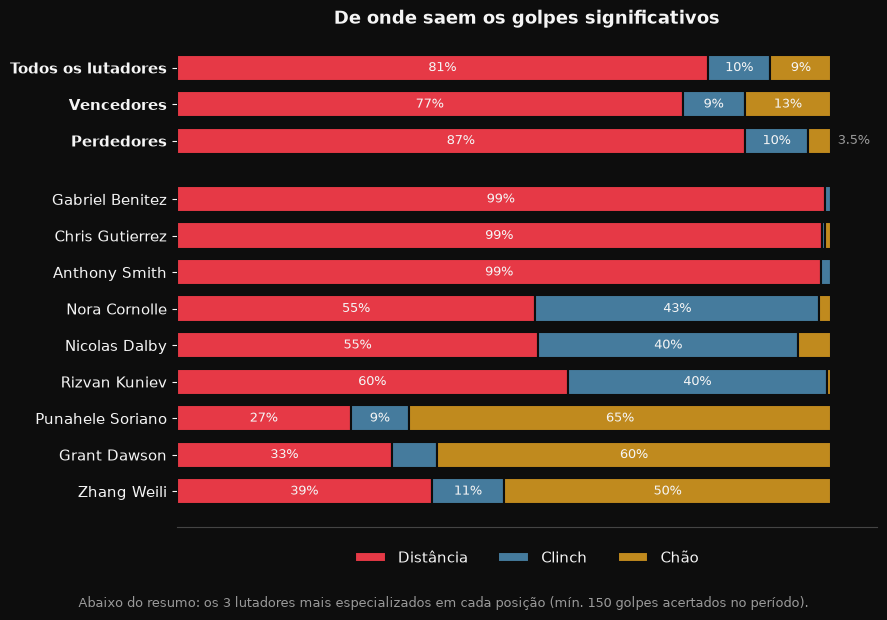

In [3]:
# De onde os golpes significativos saem: distância, clinch e chão, em % do total acertado.
# No topo: todos, vencedores e perdedores (só lutas com resultado); depois os 3 lutadores
# mais especializados em cada posição (mínimo de 150 golpes acertados no período).
import numpy as np

MIN_GOLPES_POSICAO = 150
posicoes_golpe = {"Distância": ("Distance_landed", COR_VERMELHO), "Clinch": ("Clinch_landed", COR_AZUL), "Chão": ("Ground_landed", COR_AMARELO)}
colunas_pos = [col for col, _ in posicoes_golpe.values()]


def distribuicao(dados):
    total = dados[colunas_pos].sum()
    return total / total.sum() * 100


resumo = pd.DataFrame({
    "Todos os lutadores": distribuicao(df),
    "Vencedores": distribuicao(df[df["Resultado"] == "W"]),
    "Perdedores": distribuicao(df[df["Resultado"] == "L"]),
}).T

por_lutador_pos = df.groupby("Fighter")[colunas_pos].sum()
por_lutador_pos = por_lutador_pos[por_lutador_pos.sum(axis=1) >= MIN_GOLPES_POSICAO]
pct_pos = por_lutador_pos.div(por_lutador_pos.sum(axis=1), axis=0) * 100
especialistas_pos = pd.concat([pct_pos.nlargest(3, col) for col in colunas_pos])

tabela_pos = pd.concat([resumo, especialistas_pos])
print(f"{len(por_lutador_pos)} lutadores com pelo menos {MIN_GOLPES_POSICAO} golpes acertados")
print(tabela_pos.round(1))

fig, ax = plt.subplots(figsize=(9, 6.2))
n_resumo = len(resumo)
y = [len(tabela_pos) - i + (0.6 if i < n_resumo else 0) for i in range(len(tabela_pos))]  # espaço após o resumo

esquerda = np.zeros(len(tabela_pos))
ultima = list(posicoes_golpe)[-1]
for rotulo, (coluna, cor) in posicoes_golpe.items():
    valores = tabela_pos[coluna].values
    ax.barh(y, valores, left=esquerda, color=cor, height=0.72, label=rotulo,
            edgecolor="#0d0d0d", linewidth=1.5)
    for i, (yi, x0, v) in enumerate(zip(y, esquerda, valores)):
        if v >= 7:
            ax.text(x0 + v / 2, yi, f"{v:.0f}%", ha="center", va="center", fontsize=9.5, color="#f5f5f5")
        elif rotulo == ultima and i < n_resumo:  # no resumo, o chão pequeno (perdedores) vai fora da barra
            ax.text(101, yi, f"{v:.1f}%", ha="left", va="center", fontsize=9, color="#9a9a9a")
    esquerda += valores

ax.set_yticks(y)
ax.set_yticklabels(tabela_pos.index)
for rotulo_y in ax.get_yticklabels()[:n_resumo]:
    rotulo_y.set_fontweight("bold")
ax.set_xlim(0, 107)
ax.set_xticks([])
ax.grid(False)
ax.set_title("De onde saem os golpes significativos", fontsize=13, fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False, labelcolor="#f5f5f5")
fig.text(0.5, 0.01, f"Abaixo do resumo: os 3 lutadores mais especializados em cada posição (mín. {MIN_GOLPES_POSICAO} golpes acertados no período).",
         ha="center", fontsize=9, color="#9a9a9a")

plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.savefig("../figures/origem_dos_golpes.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

240 lutadores no filtro | média geral: 35.8%
                  conseguidas  tentadas  lutas  precisao_pct
Fighter                                                     
Mason Jones                11        15      4          73.3
Andre Muniz                14        20      4          70.0
Fatima Kline               14        21      5          66.7
Joanderson Brito           14        21      8          66.7
Cory Sandhagen             10        15      5          66.7
Zhang Weili                13        20      4          65.0
Joaquin Buckley            12        19      8          63.2
Hamdy Abdelwahab           10        16      3          62.5
Lerone Murphy              10        16      6          62.5
Piera Rodriguez            18        29      5          62.1


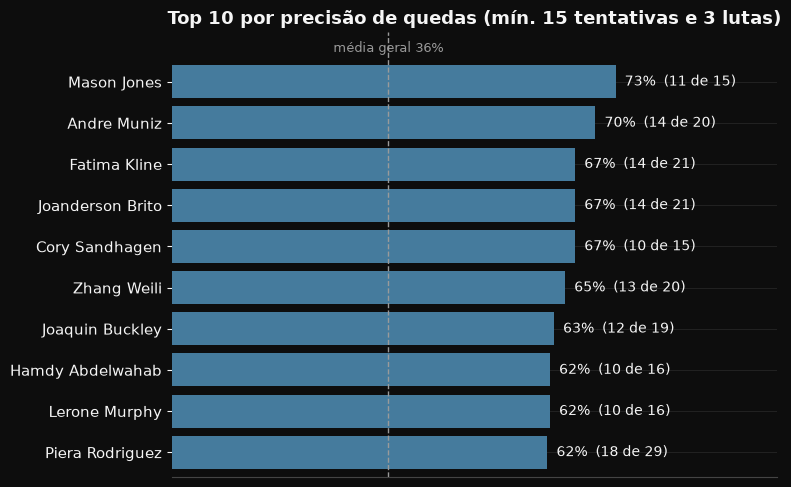

In [3]:
# Precisão de quedas: quedas conseguidas / tentadas no período.
# Mínimo de tentativas E de lutas: sem o segundo filtro, entra quem tentou muito numa luta só.
MIN_TENTATIVAS_TD = 15
MIN_LUTAS_TD = 3

quedas = df.groupby("Fighter").agg(
    conseguidas=("Td_landed", "sum"),
    tentadas=("Td_attempted", "sum"),
    lutas=("Fight_URL", "nunique"),
)
media_td = quedas["conseguidas"].sum() / quedas["tentadas"].sum() * 100
quedas = quedas[(quedas["tentadas"] >= MIN_TENTATIVAS_TD) & (quedas["lutas"] >= MIN_LUTAS_TD)]
quedas["precisao_pct"] = quedas["conseguidas"] / quedas["tentadas"] * 100

top_td = quedas.sort_values(["precisao_pct", "conseguidas"], ascending=False).head(10)
print(f"{len(quedas)} lutadores no filtro | média geral: {media_td:.1f}%")
print(top_td.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_td.index[::-1], top_td["precisao_pct"].values[::-1], color=COR_AZUL)

# Valor na ponta com "conseguidas de tentadas", para mostrar o tamanho da amostra
for barra, (_, linha) in zip(barras, top_td[::-1].iterrows()):
    ax.text(barra.get_width() + 1.5, barra.get_y() + barra.get_height() / 2,
            f"{linha['precisao_pct']:.0f}%  ({int(linha['conseguidas'])} de {int(linha['tentadas'])})",
            va="center", fontsize=10, color="#f5f5f5")

# Referência: média de todos os lutadores
ax.axvline(media_td, color="#9a9a9a", linestyle="--", linewidth=1)
ax.text(media_td, len(top_td) - 0.35, f"média geral {media_td:.0f}%", ha="center", va="bottom", fontsize=9, color="#9a9a9a")

estilizar_grafico(ax, f"Top 10 por precisão de quedas (mín. {MIN_TENTATIVAS_TD} tentativas e {MIN_LUTAS_TD} lutas)")
ax.set_xlim(0, 100)
ax.set_ylim(-0.6, len(top_td) + 0.2)

plt.tight_layout()
plt.savefig("../figures/top10_precisao_quedas.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()